# 100-window mean RPKM profiles (no CI)

For every input file, the mean RPKM is calculated separately for each of the 100 windows. Real and simulated data are plotted separately. No confidence interval or smoothing is applied.

In [6]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

BASE = Path('/cta/users/guneyn23')
RPKM_DIR = BASE / 'peak_center_20kb_100w/rpkm'
OUT = RPKM_DIR / 'mean_no_ci_plots'
OUT.mkdir(parents=True, exist_ok=True)

REGIONS = ['ATAC', 'H3K9me3', 'H3K27me3']
DAMAGES = ['CPD', '64']
KINDS = ['real', 'sim']
TIMES = ['1m', '15m', '30m', '1h', '4h', '8h']
COLORS = {
    '1m': '#01befe',
    '15m': '#ffdd00',
    '30m': '#ff7d00',
    '1h': '#ff006d',
    '4h': '#adff02',
    '8h': '#8f00ff',
}

def rpkm_path(region, damage, time, kind):
    folder = 'real' if kind == 'real' else 'simulated'
    return RPKM_DIR / folder / f'{time}_{damage}_{kind}_{region}_100windows_rpkm.bed'


## Calculate mean RPKM separately for every window

In [3]:
def means_by_window(path):
    data = pd.read_csv(
        path,
        sep='\t',
        header=None,
        usecols=[3, 5],
        names=['peak_window', 'rpkm'],
    )
    data['window'] = data['peak_window'].str.rsplit('_', n=1).str[-1].astype(int)
    return data.groupby('window', sort=True)['rpkm'].mean().reset_index(name='mean_rpkm')

summaries = []

for region in REGIONS:
    for damage in DAMAGES:
        for kind in KINDS:
            for time in TIMES:
                path = rpkm_path(region, damage, time, kind)
                print('Reading:', path.name)
                table = means_by_window(path)
                table.insert(0, 'time', time)
                table.insert(0, 'kind', kind)
                table.insert(0, 'damage', damage)
                table.insert(0, 'region', region)
                table['distance_kb'] = -10 + (table['window'] - 0.5) * 0.2
                summaries.append(table)

summary = pd.concat(summaries, ignore_index=True)
summary.to_csv(OUT / '100windows_mean_rpkm_no_ci_summary.tsv', sep='\t', index=False)
summary.head()


Reading: 1m_CPD_real_ATAC_100windows_rpkm.bed


ParserError: Error tokenizing data. C error: Calling read(nbytes) on source failed. Try engine='python'.

In [8]:
summary = pd.read_csv(
    OUT / '100windows_mean_rpkm_no_ci_summary.tsv',
    sep='\t'
)

## Plot mean profiles without CI or smoothing

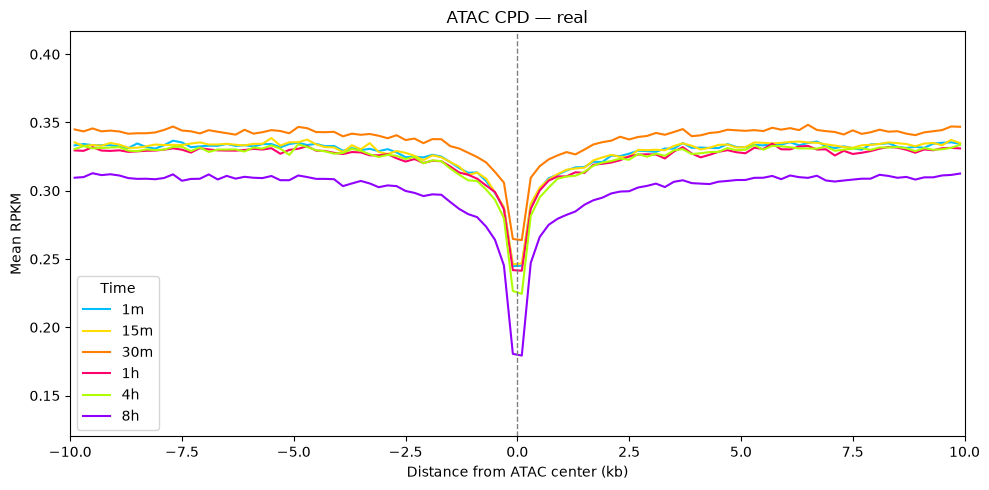

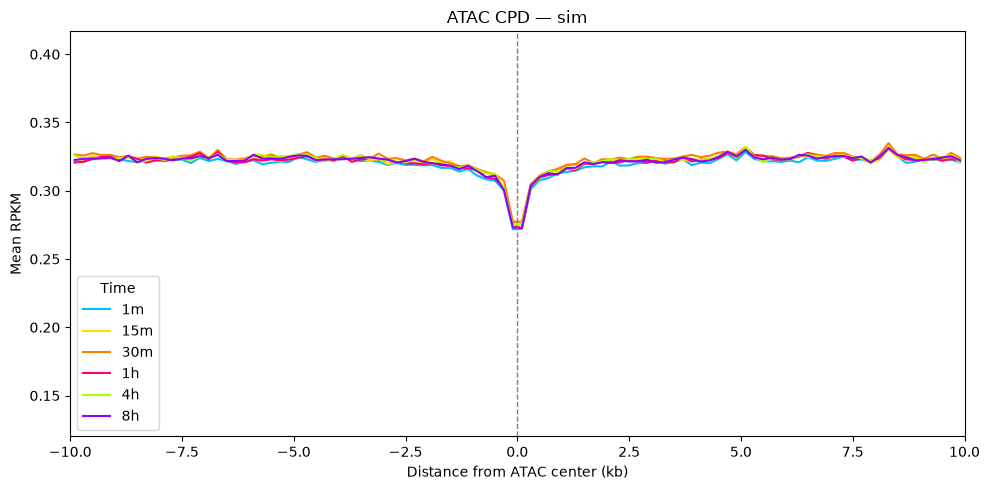

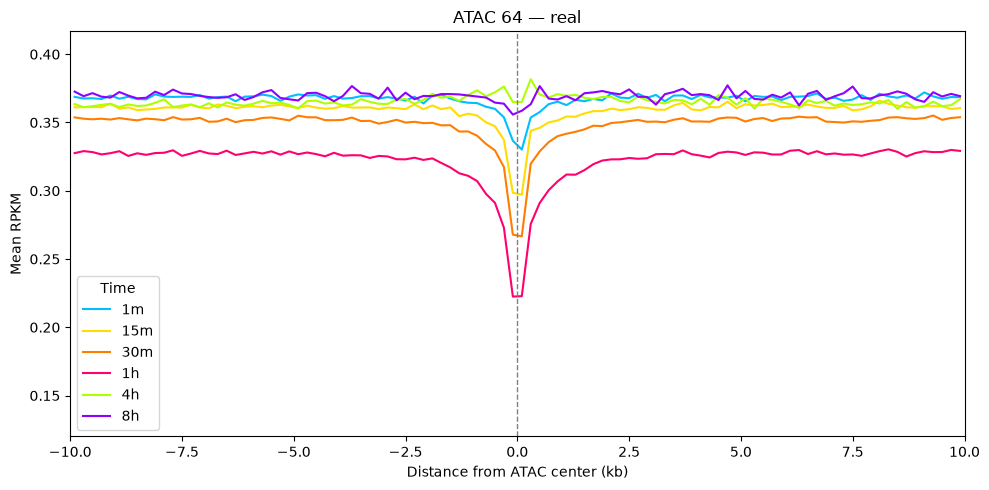

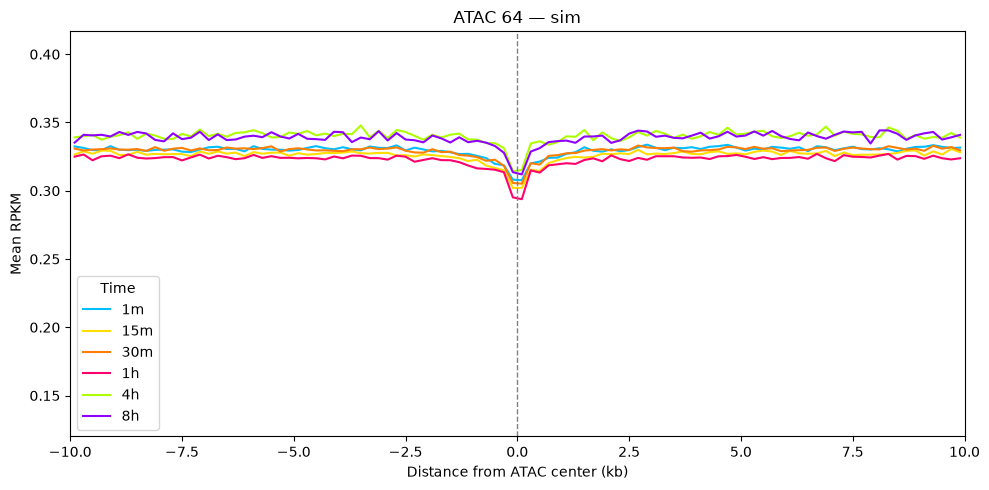

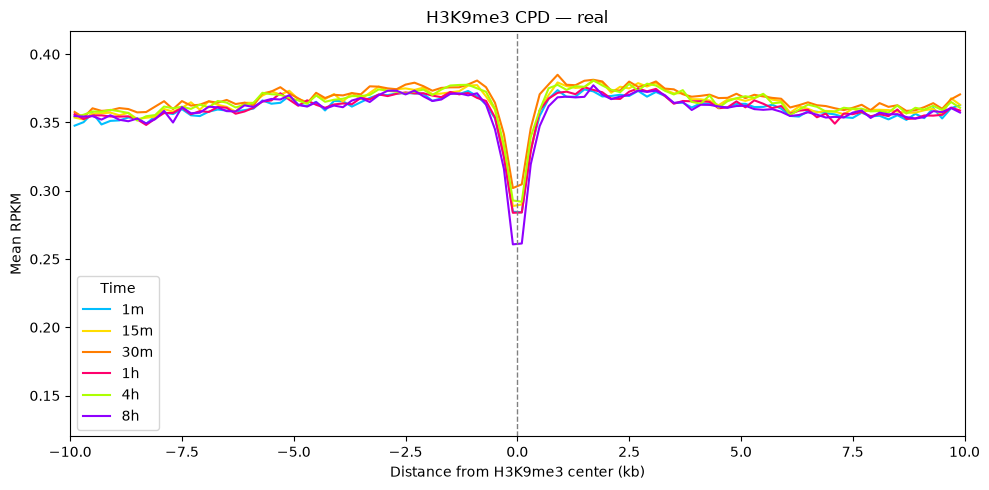

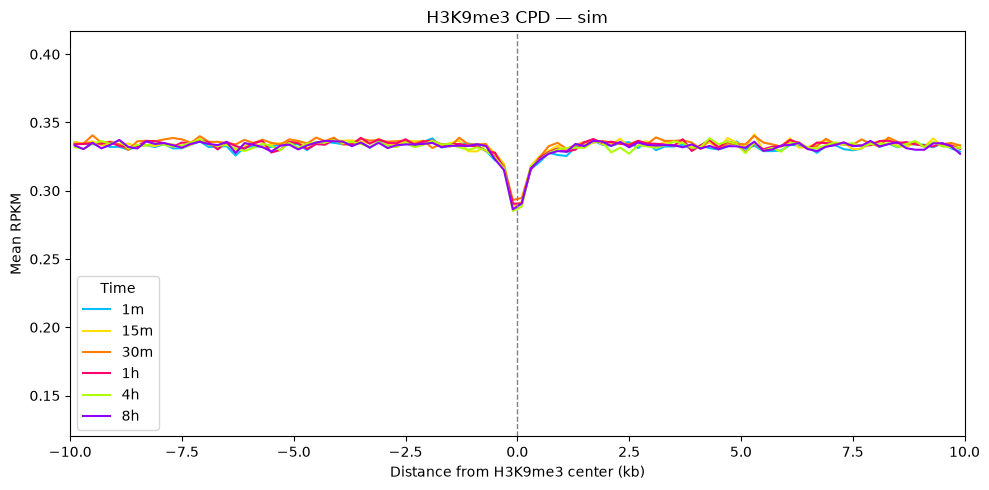

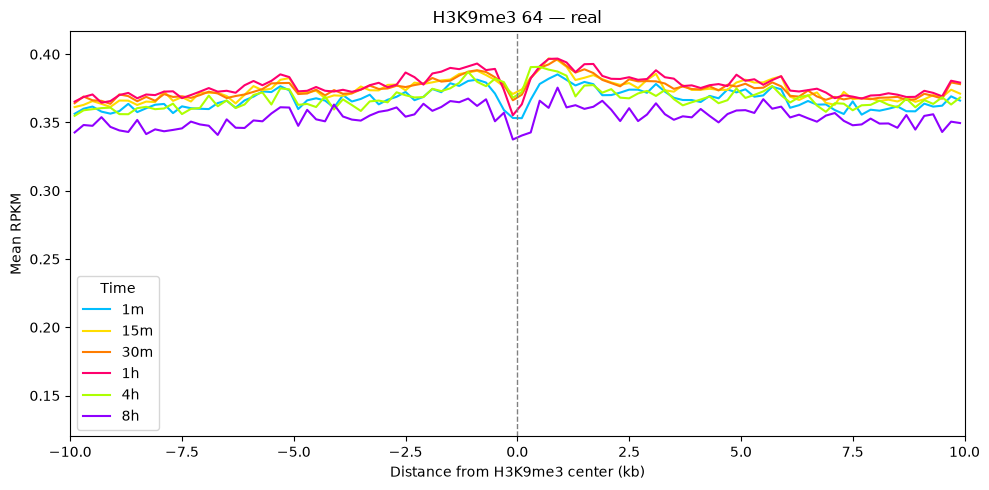

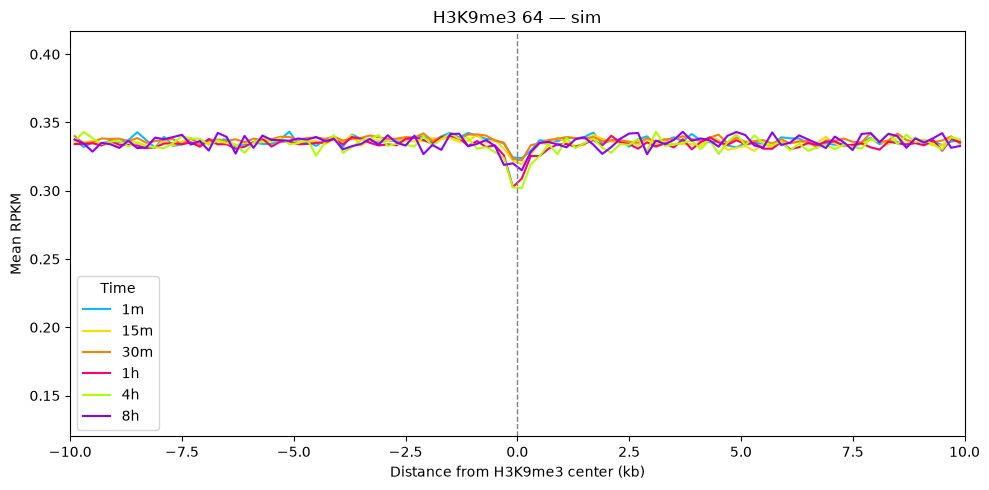

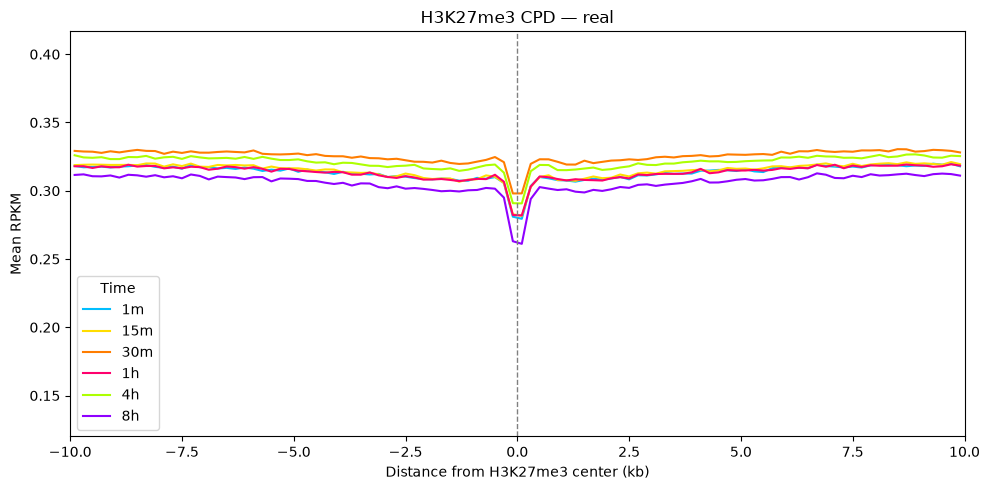

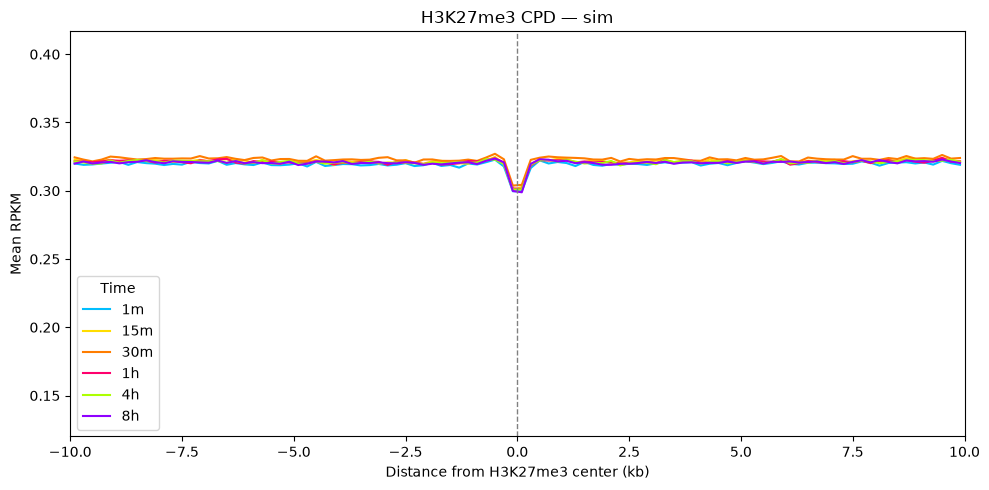

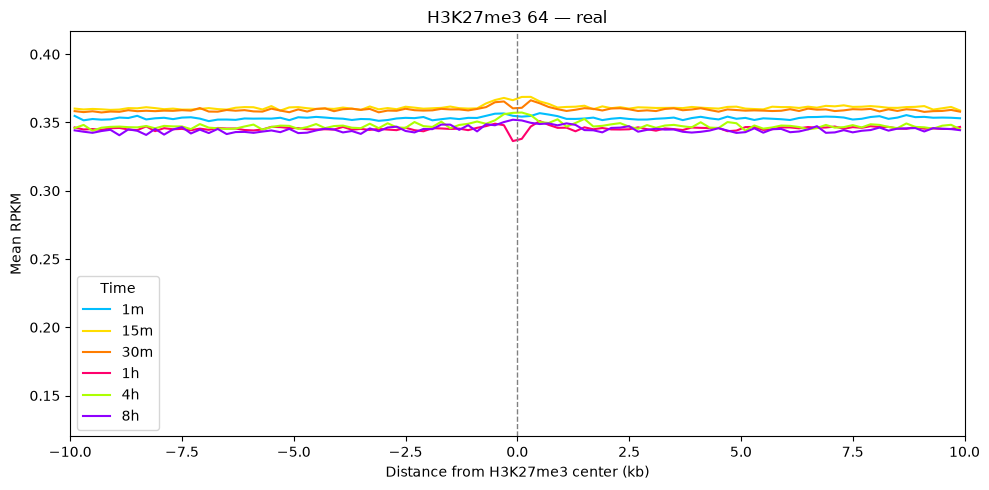

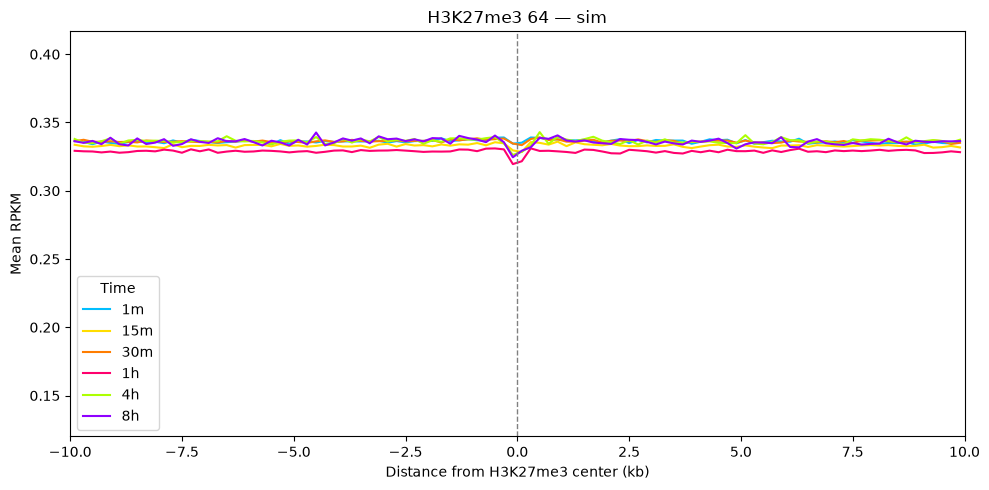

In [10]:
# Use one common y-axis range for every raw mean plot.
RAW_Y_MIN = 0.12
RAW_Y_MAX = summary['mean_rpkm'].max() * 1.05

for region in REGIONS:
    for damage in DAMAGES:
        for kind in KINDS:
            selected = summary[
                (summary['region'] == region)
                & (summary['damage'] == damage)
                & (summary['kind'] == kind)
            ]

            fig, ax = plt.subplots(figsize=(10, 5))

            for time in TIMES:
                values = selected[selected['time'] == time].sort_values('window')
                ax.plot(
                    values['distance_kb'],
                    values['mean_rpkm'],
                    color=COLORS[time],
                    label=time,
                )

            ax.axvline(0, color='gray', linestyle='--', linewidth=1)
            ax.set_xlim(-10, 10)
            ax.set_ylim(RAW_Y_MIN, RAW_Y_MAX)
            ax.set_xlabel(f'Distance from {region} center (kb)')
            ax.set_ylabel('Mean RPKM')
            ax.set_title(f'{region} {damage} — {kind}')
            ax.legend(title='Time')
            fig.tight_layout()
            fig.savefig(
                OUT / f'{region}_{damage}_{kind}_mean_rpkm_no_ci.png',
                dpi=300,
                bbox_inches='tight',
            )
            plt.show()
            plt.close(fig)


## Real/Sim-normalized profiles for CPD and 6-4PP

For each region, damage type, time point and window: `normalized = real mean RPKM / simulated mean RPKM`. A simulated mean of zero is replaced with `NaN` to avoid division by zero.

In [11]:
real_mean = summary[summary['kind'] == 'real'][
    ['region', 'damage', 'time', 'window', 'distance_kb', 'mean_rpkm']
].rename(columns={'mean_rpkm': 'real_mean_rpkm'})

sim_mean = summary[summary['kind'] == 'sim'][
    ['region', 'damage', 'time', 'window', 'mean_rpkm']
].rename(columns={'mean_rpkm': 'sim_mean_rpkm'})

normalized = real_mean.merge(
    sim_mean,
    on=['region', 'damage', 'time', 'window'],
    validate='one_to_one',
)

normalized['real_div_sim'] = (
    normalized['real_mean_rpkm']
    / normalized['sim_mean_rpkm'].replace(0, np.nan)
)

normalized.to_csv(
    OUT / '100windows_mean_rpkm_real_div_sim.tsv',
    sep='\t',
    index=False,
)
normalized.head()


,region,damage,time,window,distance_kb,real_mean_rpkm,sim_mean_rpkm,real_div_sim
0,ATAC,CPD,1m,1,-9.9,0.333243,0.321679,1.035950
1,ATAC,CPD,1m,2,-9.7,0.334232,0.322042,1.037852
2,ATAC,CPD,1m,3,-9.5,0.333386,0.323122,1.031765
3,ATAC,CPD,1m,4,-9.3,0.333349,0.323243,1.031262
4,ATAC,CPD,1m,5,-9.1,0.333392,0.323594,1.030276


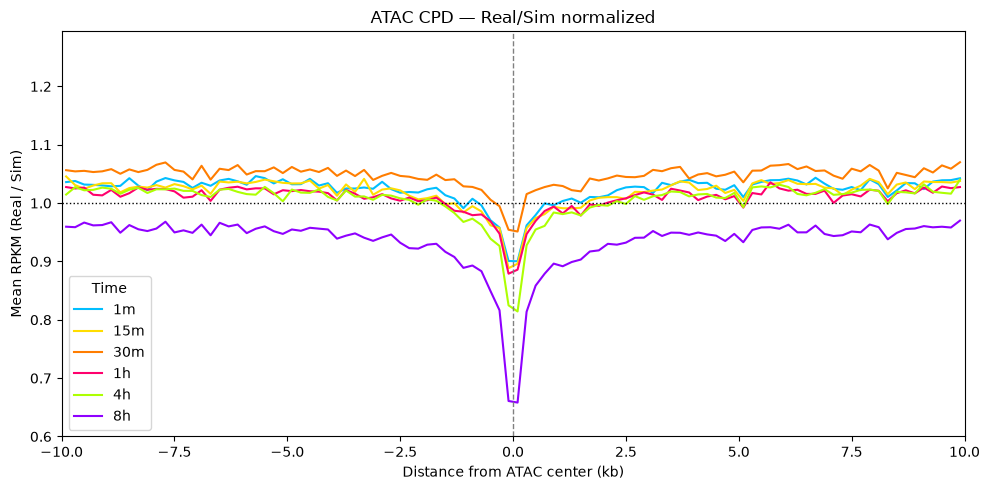

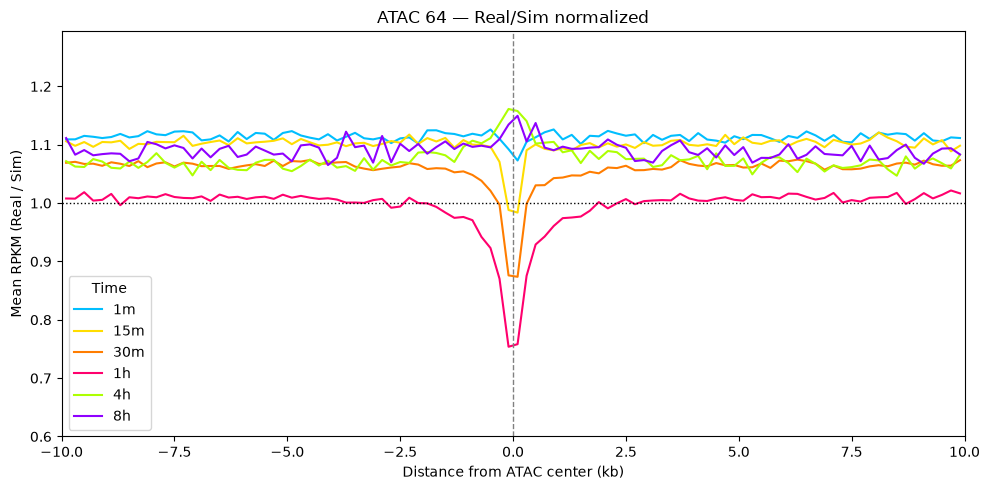

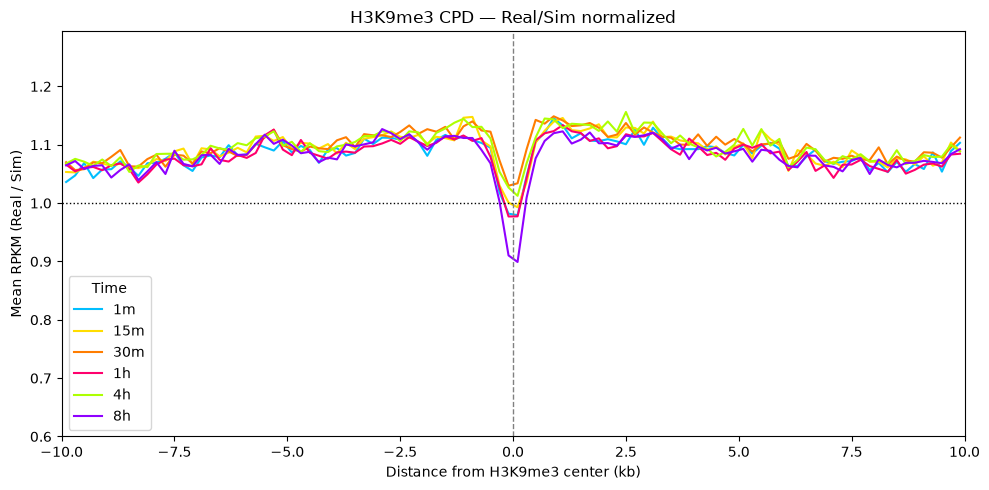

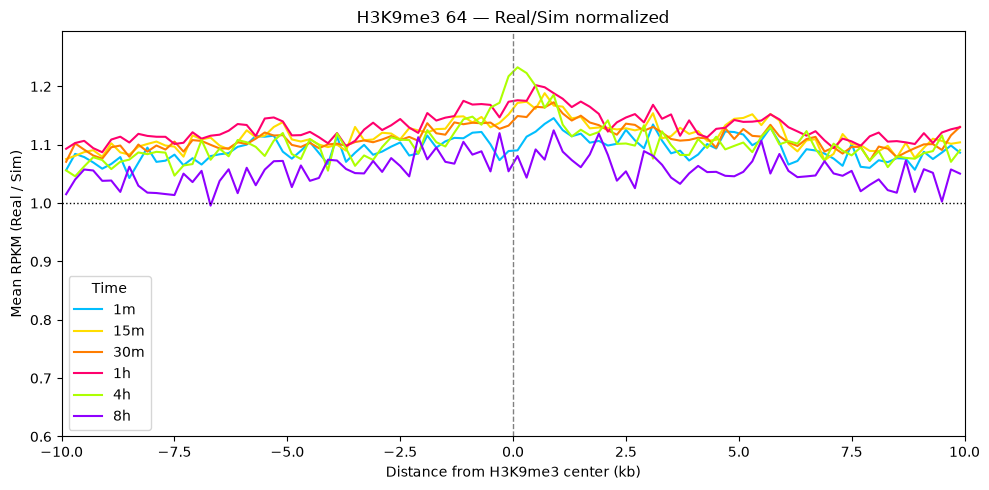

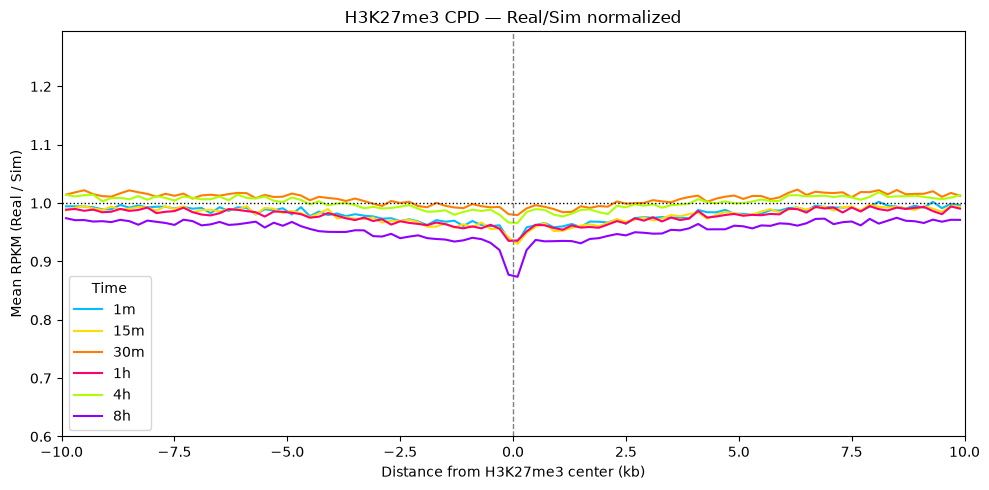

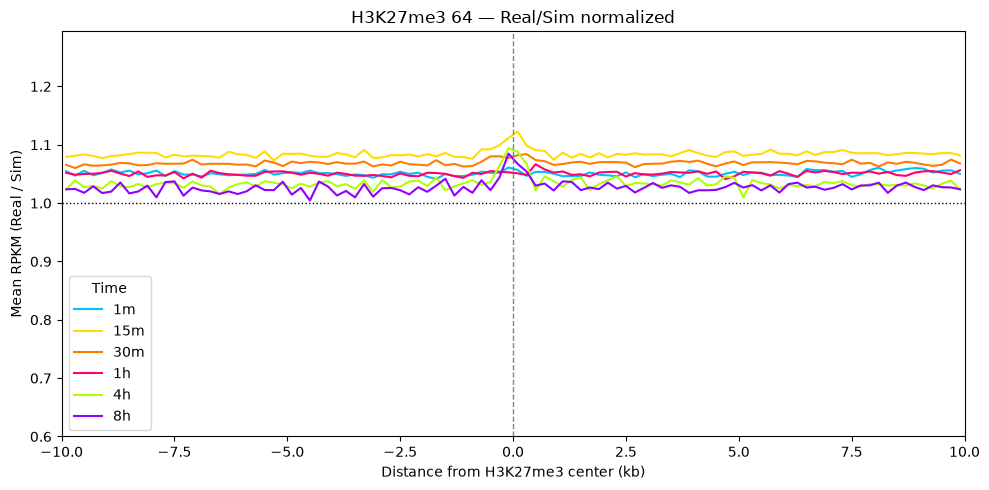

In [13]:
# CPD and 64 normalized plots also share one common y-axis range.
finite_ratios = normalized['real_div_sim'].replace([np.inf, -np.inf], np.nan).dropna()
RATIO_Y_MIN = 0.6
RATIO_Y_MAX = finite_ratios.max() * 1.05

for region in REGIONS:
    for damage in DAMAGES:
        selected = normalized[
            (normalized['region'] == region)
            & (normalized['damage'] == damage)
        ]

        fig, ax = plt.subplots(figsize=(10, 5))

        for time in TIMES:
            values = selected[selected['time'] == time].sort_values('window')
            ax.plot(
                values['distance_kb'],
                values['real_div_sim'],
                color=COLORS[time],
                label=time,
            )

        ax.axhline(1, color='black', linestyle=':', linewidth=1)
        ax.axvline(0, color='gray', linestyle='--', linewidth=1)
        ax.set_xlim(-10, 10)
        ax.set_ylim(RATIO_Y_MIN, RATIO_Y_MAX)
        ax.set_xlabel(f'Distance from {region} center (kb)')
        ax.set_ylabel('Mean RPKM (Real / Sim)')
        ax.set_title(f'{region} {damage} — Real/Sim normalized')
        ax.legend(title='Time')
        fig.tight_layout()
        fig.savefig(
            OUT / f'{region}_{damage}_mean_rpkm_real_div_sim.png',
            dpi=300,
            bbox_inches='tight',
        )
        plt.show()
        plt.close(fig)
